# Module 5 — Operator Learning with DeepONet

**DesignSafe AI Training**

[![Try on DesignSafe](https://raw.githubusercontent.com/DesignSafe-CI/training-ai/main/DesignSafe-Badge.svg)](https://jupyter.designsafe-ci.org/hub/user-redirect/lab/tree/CommunityData/Training/2026-SPARC/Day3/3b-SciML/05b-deeponet-cantilever.ipynb) [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DesignSafe-CI/training-ai/blob/main/05-operator-learning/05b-deeponet-cantilever.ipynb)

> Cantilever DeepONet example after Somdatta Goswami (Johns Hopkins).

---

## A PINN solves one load case and only one

Module 4's PINN solved the beam from the equation alone, with no labelled data.
Then we noticed the catch: it solved **one load case**. Change the load and every
weight is wrong. Minutes of optimisation per load, when a design study needs
hundreds.

Look at the pattern across the session:

| Module | Learns | Maps | New query costs |
| --- | --- | --- | --- |
| 1 Regression | 3 coefficients | $\mathbb{R}^3 \to \mathbb{R}$ | instant |
| 2 MLP | a nonlinear surrogate | $\mathbb{R}^3 \to \mathbb{R}$ | instant |
| 4 PINN | one solution field | $x \mapsto w(x)$ | **retrain (minutes)** |
| 5 DeepONet | the solution **operator** | $q(\cdot) \mapsto w(\cdot)$ | instant |

The last row is the one we build now: a single trained network that takes a
*whole load function* as input and returns the *whole deflection field*, for any
load in the family — without retraining.

## 1000 GRF load cases on a 2 m x 0.2 m cantilever

A 2 m x 0.2 m linear-elastic cantilever under a displacement-controlled boundary
condition. The applied displacement profile is drawn from a Gaussian random
field, so no two load cases look alike. For each one, a finite element solve gives
the full 2D displacement field.

<img src="figs/deeponet-cantilever-schematic.png" width="900"/>

We have **1000** such (load, field) pairs. We want the map between them.



| 5 | Zero-shot prediction, and the limits |

## Setup

In [1]:
%pip install torch scipy matplotlib numpy --quiet

/private/tmp/claude-501/-Users-krishna-dev-DesignSafe-Training/a3c591bf-7af0-4642-a72e-3ed72e972147/scratchpad/venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.io import loadmat

RNG = 42
torch.manual_seed(RNG)
np.random.seed(RNG)

plt.rcParams.update({"figure.figsize": (11, 4), "font.size": 11})
MAT_NAME = "cantilever_beam_deflection.mat"


def find_mat():
    """The 20 MB dataset: Community Data, then local, then GitHub."""
    here = Path.cwd()
    for c in [Path("/home/jupyter/CommunityData/Training/2026-SPARC/Day3/3b-SciML") / MAT_NAME,
              here / MAT_NAME,
              here / "05-operator-learning" / MAT_NAME,
              here.parent / "training-deeponet" / MAT_NAME]:
        if c.exists():
            print(f"using {c}")
            return str(c)
    import urllib.request
    print("downloading 20 MB from GitHub (one time)...")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/DesignSafe-Training/deeponet/refs/heads/main/cantilever_beam_deflection.mat", MAT_NAME)
    return MAT_NAME


print("torch", torch.__version__)

torch 2.13.0


## 100 input sensors in, a 1314-node field out

In [3]:
raw = loadmat(find_mat())

u_all = raw["app_disp"]                                     # (1000, 100) input functions
xy = np.stack([raw["coord_x"].ravel(), raw["coord_y"].ravel()], axis=1)   # (1314, 2)
sx_all = raw["disp_x"]                                      # (1000, 1314)
sy_all = raw["disp_y"]
sensor_loc = raw["sensor_loc_disp"].ravel()                  # (100,)

N_SAMPLES, N_SENSORS = u_all.shape
N_NODES = xy.shape[0]

print(f"  {N_SAMPLES} load cases")
print(f"  input  function sampled at {N_SENSORS} sensors, x in "
      f"[{sensor_loc.min():.2f}, {sensor_loc.max():.2f}] m")
print(f"  output field on {N_NODES} FE nodes, "
      f"x in [{xy[:,0].min():.2f}, {xy[:,0].max():.2f}] m, "
      f"y in [{xy[:,1].min():.2f}, {xy[:,1].max():.2f}] m")
print(f"  output has 2 components (u_x, u_y)")
print(f"\n  that is {N_SAMPLES * N_NODES * 2:,} field values in total")

using /Users/krishna/dev/DesignSafe-Training/training-ai/05-operator-learning/cantilever_beam_deflection.mat
  1000 load cases
  input  function sampled at 100 sensors, x in [0.00, 2.00] m
  output field on 1314 FE nodes, x in [0.00, 2.00] m, y in [0.00, 0.20] m
  output has 2 components (u_x, u_y)

  that is 2,628,000 field values in total


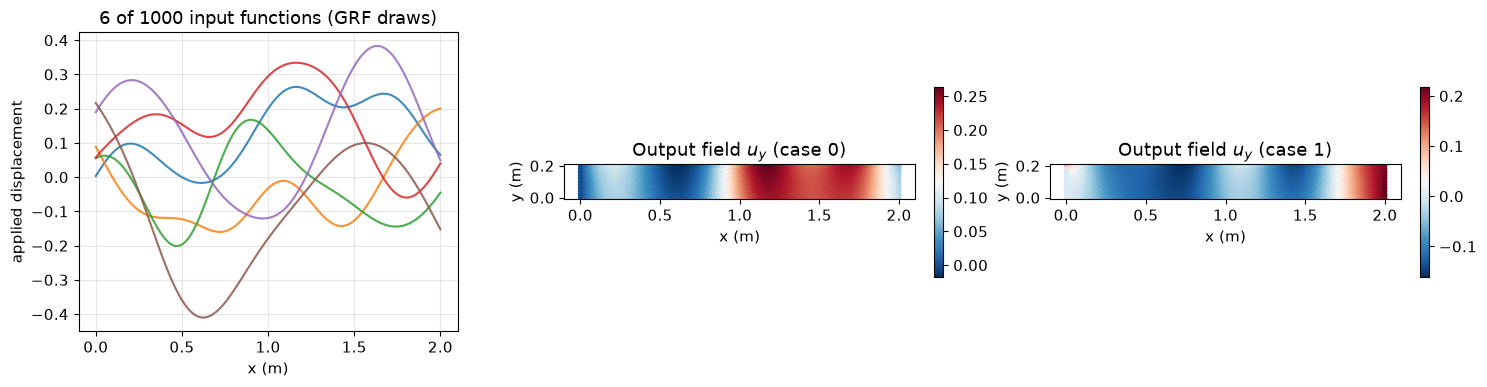

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i in range(6):
    ax[0].plot(sensor_loc, u_all[i], lw=1.5, alpha=.85)
ax[0].set(xlabel="x (m)", ylabel="applied displacement",
          title=f"6 of {N_SAMPLES} input functions (GRF draws)")
ax[0].grid(alpha=.3)

for a, comp, name in ((ax[1], sy_all[0], "$u_y$ (case 0)"),
                      (ax[2], sy_all[1], "$u_y$ (case 1)")):
    sc = a.scatter(xy[:, 0], xy[:, 1], c=comp, s=7, cmap="RdBu_r")
    a.set(xlabel="x (m)", ylabel="y (m)", title=f"Output field {name}")
    a.set_aspect("equal")
    plt.colorbar(sc, ax=a, fraction=.025)

plt.tight_layout(); plt.show()

Each input is a *function* — a displacement profile along the beam — not a
handful of scalars. Each output is a *field* on 1314 nodes. That is the shape of
the problem operator learning is built for.

## Part 1 — From functions to operators

Modules 2 and 3 approximated **functions**: $f: \mathbb{R}^d \to \mathbb{R}$, a
finite vector in, a number out. An **operator** maps a function to a function:

$$\mathcal{G}: \mathcal{U} \to \mathcal{S}, \qquad
u(\cdot) \;\longmapsto\; s(\cdot) = \mathcal{G}(u)(\cdot)$$

Our target is the solution operator of the beam: given the applied displacement
profile $u$, return the displacement field $s$.

<img src="figs/operator_concept.png" width="760"/>

### A function is infinite-dimensional; a network takes vectors

A function lives in an infinite-dimensional space. Networks take finite vectors.

The standard resolution is to **discretise the input**: evaluate $u$ at $m$ fixed
sensor locations and feed the vector $[u(x_1), \dots, u(x_m)]$. Our data already
does this, with $m = 100$.

Note the asymmetry, because it matters later: the *input* is pinned to those 100
sensors, but the *output* can be queried at any $(x, y)$ we like. A DeepONet is
mesh-free in its output and fixed-grid in its input. (Fourier Neural Operators
relax the input side too — see Part 5.)

### Why not just concatenate everything into one MLP?

The obvious baseline: build a 102-dimensional input $[u_1, \dots, u_{100}, x, y]$
and map it to $(u_x, u_y)$ with a plain MLP. Nothing stops you. Let's find out
whether DeepONet's structure earns its place, rather than assuming it.

In [5]:
# --- split, normalise (statistics from the training split only) ---
N_TRAIN = 800
idx_tr, idx_te = np.arange(N_TRAIN), np.arange(N_TRAIN, N_SAMPLES)

s_all = np.stack([sx_all, sy_all], axis=-1)          # (1000, 1314, 2)

u_mu, u_sd = u_all[idx_tr].mean(), u_all[idx_tr].std()
s_sd = s_all[idx_tr].reshape(-1, 2).std(0)           # per component
xy_lo, xy_hi = xy.min(0), xy.max(0)

T = lambda a: torch.tensor(a, dtype=torch.float32)
U_tr, U_te = T((u_all[idx_tr] - u_mu) / u_sd), T((u_all[idx_te] - u_mu) / u_sd)
S_tr, S_te = T(s_all[idx_tr] / s_sd), T(s_all[idx_te] / s_sd)
XY = T(2 * (xy - xy_lo) / (xy_hi - xy_lo) - 1)       # -> [-1, 1]^2

print(f"train {len(U_tr)} cases   test {len(U_te)} cases")
print(f"output std per component: u_x {s_sd[0]:.4f}, u_y {s_sd[1]:.4f}")
print("y spans 0.2 m and x spans 2 m, so the coordinates are rescaled to "
      "[-1,1] -- otherwise the trunk barely sees y")

train 800 cases   test 200 cases
output std per component: u_x 0.0411, u_y 0.1959
y spans 0.2 m and x spans 2 m, so the coordinates are rescaled to [-1,1] -- otherwise the trunk barely sees y


In [6]:
def mlp(sizes, act=nn.Tanh):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2:
            layers.append(act())
    return nn.Sequential(*layers)


def rel_l2(pred, true):
    """Per-case relative L2 error in physical units, as a percentage."""
    p = pred.reshape(len(pred), -1)
    t = true.reshape(len(true), -1)
    return np.linalg.norm(p - t, axis=1) / np.linalg.norm(t, axis=1) * 100


class NaiveMLP(nn.Module):
    """Concatenate the 100 sensor values with (x, y) and regress."""

    def __init__(self, m=N_SENSORS, width=128, depth=5):
        super().__init__()
        self.net = mlp([m + 2] + [width] * depth + [2])

    def forward(self, U, XY):
        B, Q = U.shape[0], XY.shape[0]
        Ue = U.unsqueeze(1).expand(B, Q, U.shape[1])       # (B, Q, m)
        Xe = XY.unsqueeze(0).expand(B, Q, 2)               # (B, Q, 2)
        return self.net(torch.cat([Ue, Xe], dim=-1))       # (B, Q, 2)


def train_operator(model, epochs=400, lr=1e-3, bs=64, n_query=None,
                   eval_every=20, quiet=False, tag=""):
    """Minibatch Adam over load cases.

    n_query: if set, use a random subset of that many query points per step.
             The naive MLP needs this -- see the cost note below. The DeepONet
             uses all 1314 nodes every step because it can afford to.
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {"train": [], "test": [], "test_epoch": []}
    t0 = time.time()
    for ep in range(epochs):
        perm = torch.randperm(len(U_tr))
        run = 0.0
        for i in range(0, len(U_tr), bs):
            b = perm[i:i + bs]
            if n_query is None:
                q, S = XY, S_tr[b]
            else:
                qi = torch.randint(0, len(XY), (n_query,))
                q, S = XY[qi], S_tr[b][:, qi]
            opt.zero_grad()
            loss = ((model(U_tr[b], q) - S) ** 2).mean()
            loss.backward(); opt.step()
            run += loss.item()
        sched.step()
        hist["train"].append(run / max(1, len(U_tr) // bs))
        # Evaluating the full test set is itself expensive for the naive model,
        # so do it periodically rather than every epoch.
        if ep % eval_every == 0 or ep == epochs - 1:
            with torch.no_grad():
                hist["test"].append(((model(U_te, XY) - S_te) ** 2).mean().item())
            hist["test_epoch"].append(ep)
            if not quiet:
                print(f"  {tag} epoch {ep:>4d}  train {hist['train'][-1]:.3e}  "
                      f"test {hist['test'][-1]:.3e}  [{time.time()-t0:.0f}s]")
    hist["seconds"] = time.time() - t0
    return hist


torch.manual_seed(RNG)
naive = NaiveMLP()
n_naive = sum(p.numel() for p in naive.parameters())
print(f"NaiveMLP: {n_naive:,} parameters")
h_naive = train_operator(naive, epochs=400, n_query=128, tag="naive")

with torch.no_grad():
    r_naive = rel_l2((naive(U_te, XY).numpy() * s_sd), S_te.numpy() * s_sd)
print(f"\nnaive MLP: mean relative L2 = {r_naive.mean():.2f}%  "
      f"(worst case {r_naive.max():.2f}%)  in {h_naive['seconds']:.0f}s")

NaiveMLP: 79,490 parameters


  naive epoch    0  train 9.608e-01  test 8.760e-01  [0s]


  naive epoch   20  train 4.947e-01  test 4.684e-01  [2s]


  naive epoch   40  train 1.189e-01  test 9.400e-02  [4s]


  naive epoch   60  train 4.931e-02  test 4.629e-02  [6s]


...

  naive epoch  320  train 5.962e-03  test 6.613e-03  [32s]


  naive epoch  340  train 6.732e-03  test 6.428e-03  [34s]


  naive epoch  360  train 6.078e-03  test 6.328e-03  [36s]


  naive epoch  380  train 5.953e-03  test 6.267e-03  [38s]


  naive epoch  399  train 6.469e-03  test 6.255e-03  [40s]

naive MLP: mean relative L2 = 6.82%  (worst case 15.84%)  in 40s


Keep that number. The DeepONet will get the same parameter budget, the
same optimiser, and the same number of epochs.

### One detail that is not a detail: `n_query=128`

The naive model had to be trained on a random **subset** of 128 query points per
step, while the DeepONet below trains on all 1314 every step. That is not us
handicapping the baseline — it is the baseline being unaffordable otherwise.

The reason is structural. To predict at $Q$ points, the naive model must push
the 100 sensor values through its layers $Q$ separate times, because they are
concatenated with the coordinates before the first layer. At 1314 nodes that is
1314 copies of the same input function through the same weights.

We measure exactly how much that costs in Part 3, once we have something to
compare it against.

## Part 2 — The operator universal approximation theorem

Module 2 leaned on Cybenko/Hornik: networks are dense in $C(K)$. There is an
operator analogue, and it is older than you might expect.

> **Theorem (Chen & Chen, 1995).** Let $\sigma$ be a continuous non-polynomial
> activation, $K_1 \subset \mathbb{R}^d$ and $V \subset C(K_1)$ compact, and
> $\mathcal{G}: V \to C(K_2)$ a continuous operator. Then for any
> $\varepsilon > 0$ there are $m$ sensor points $x_j$, integers $p$, and network
> weights such that
> $$\left|\; \mathcal{G}(u)(y) \;-\; \sum_{k=1}^{p}
> \underbrace{b_k\!\left(u(x_1), \dots, u(x_m)\right)}_{\text{branch}}
> \cdot \underbrace{t_k(y)}_{\text{trunk}} \;\right| < \varepsilon$$
> for all $u \in V$ and all $y \in K_2$.

### The sum of products *is* branch times trunk

That sum **is** DeepONet. Lu et al. (2019) took the theorem literally and made
both factors neural networks:

$$\mathcal{G}_\theta(u)(y) = \sum_{k=1}^{p} b_k(u)\, t_k(y) + b_0$$

| Piece | Input | Output | Role |
| --- | --- | --- | --- |
| **Branch** net | $u$ at $m$ sensors | $p$ coefficients | encodes *which* load case this is |
| **Trunk** net | a query point $y$ | $p$ basis values | builds a basis over the domain |
| Inner product | | one field value | combines them |

<img src="figs/deeponet-arch.png" width="720"/>

### The trunk is shared, so it is computed once per batch

The trunk depends only on $y$, never on $u$. So it learns **one shared set of
basis functions** for the entire family of load cases, and the branch only has to
say how much of each basis function this particular load needs.

That should look familiar. It is the structure of a modal or spectral expansion —
$w(x) = \sum_k c_k \phi_k(x)$ — except that the basis $\phi_k$ is *learned from
data* rather than assumed. In Part 4 we plot the $t_k$ and compare them to what a
structural engineer would expect.

Practical consequences:

- The trunk is evaluated **once** for all query points, then reused for every load
  case in the batch. That is what the naive MLP could not do.
- Querying a new point is a trunk forward pass — the output is mesh-free.
- You get an interpretable object out: a basis.

## Part 3 — Implementation

Two subtleties.

**Two output components.** We need $u_x$ and $u_y$. Rather than two separate
networks, have branch and trunk each emit $2p$ values and read them as
$2 \times p$ — one set of coefficients and one basis per component.

**The contraction.** With a batch of $B$ load cases and $Q$ query points we want
a $(B, Q, 2)$ output from a $(B, 2, p)$ branch and a $(Q, 2, p)$ trunk. That is
one `einsum`:

```python
torch.einsum("bop,qop->bqo", branch_out, trunk_out)
```

summing over the basis index `p` while keeping batch `b`, query `q`, and
component `o` — no loops, no broadcasting by hand.

In [7]:
class DeepONet(nn.Module):
    """G(u)(y) = sum_k b_k(u) * t_k(y) + bias, per output component."""

    def __init__(self, m=N_SENSORS, p=100, width=128, depth=5, n_out=2):
        super().__init__()
        self.p, self.n_out = p, n_out
        self.branch = mlp([m] + [width] * depth + [p * n_out])
        self.trunk = mlp([2] + [width] * depth + [p * n_out])
        self.bias = nn.Parameter(torch.zeros(n_out))

    def forward(self, U, XY):
        B = self.branch(U).view(-1, self.n_out, self.p)     # (B, out, p)
        Tk = self.trunk(XY).view(-1, self.n_out, self.p)    # (Q, out, p)
        return torch.einsum("bop,qop->bqo", B, Tk) + self.bias

    def basis(self, XY):
        """The learned trunk basis, shape (Q, n_out, p)."""
        with torch.no_grad():
            return self.trunk(XY).view(-1, self.n_out, self.p)

    def coeffs(self, U):
        """Branch coefficients per load case, shape (B, n_out, p)."""
        with torch.no_grad():
            return self.branch(U).view(-1, self.n_out, self.p)


torch.manual_seed(RNG)
don = DeepONet(p=100, width=128, depth=5)
n_don = sum(q.numel() for q in don.parameters())
print(f"DeepONet: {n_don:,} parameters "
      f"(naive MLP had {sum(q.numel() for q in naive.parameters()):,})")

DeepONet: 197,010 parameters (naive MLP had 79,490)


### First, the cost claim from Part 1, measured

Same batch, same number of query points, one training step each.

In [8]:
def time_step(model, n_query, reps=3):
    """Seconds per training step for one batch of 64 at n_query query points."""
    qi = torch.randint(0, len(XY), (n_query,))
    q, S = XY[qi], S_tr[:64][:, qi]
    opt = torch.optim.Adam(model.parameters(), lr=1e-12)     # timing only
    for _ in range(2):                                       # warm up
        opt.zero_grad(); ((model(U_tr[:64], q) - S) ** 2).mean().backward(); opt.step()
    t0 = time.time()
    for _ in range(reps):
        opt.zero_grad()
        ((model(U_tr[:64], q) - S) ** 2).mean().backward()
        opt.step()
    return (time.time() - t0) / reps


print(f"  {'query points':>13s} {'naive MLP':>12s} {'DeepONet':>12s} {'ratio':>8s}")
for nq in (128, 512, N_NODES):
    a = time_step(naive, nq)
    b = time_step(don, nq)
    print(f"  {nq:>13d} {a*1000:>10.1f}ms {b*1000:>10.1f}ms {a/b:>7.1f}x")

print(f"\n  The naive model's cost grows with the number of query points because")
print(f"  it re-encodes the input function at each one. The DeepONet's barely")
print(f"  moves: the branch runs once, and only the trunk sees the extra points.")

   query points    naive MLP     DeepONet    ratio
            128        7.3ms        2.2ms     3.3x


            512       26.5ms        4.3ms     6.2x


           1314       69.9ms        4.6ms    15.2x

  The naive model's cost grows with the number of query points because
  it re-encodes the input function at each one. The DeepONet's barely
  moves: the branch runs once, and only the trunk sees the extra points.


That ratio is the architecture's justification. It is also why the naive
baseline had to be trained on 128 sampled points while the DeepONet trains on all
1314 — so bear in mind the accuracy comparison below actually *favours* the
baseline, since it is the one that got the cheaper problem.

### Same optimiser and epochs as the baseline

Same optimiser, same epochs, same batch size as the naive baseline — but all 1314
query points per step.

In [9]:
h_don = train_operator(don, epochs=400, tag="deeponet")

with torch.no_grad():
    pred_te = don(U_te, XY).numpy() * s_sd
true_te = S_te.numpy() * s_sd
r_don = rel_l2(pred_te, true_te)

print(f"\n{'model':<12s} {'params':>10s} {'seconds':>9s} {'mean rel L2':>13s} {'worst':>9s}")
print(f"{'naive MLP':<12s} {sum(p.numel() for p in naive.parameters()):>10,} "
      f"{h_naive['seconds']:>9.0f} {r_naive.mean():>12.2f}% {r_naive.max():>8.2f}%")
print(f"{'DeepONet':<12s} {n_don:>10,} {h_don['seconds']:>9.0f} "
      f"{r_don.mean():>12.2f}% {r_don.max():>8.2f}%")

  deeponet epoch    0  train 7.706e-01  test 6.541e-01  [0s]


  deeponet epoch   20  train 6.500e-02  test 5.722e-02  [1s]


  deeponet epoch   40  train 2.870e-02  test 3.521e-02  [3s]


  deeponet epoch   60  train 2.793e-02  test 2.726e-02  [4s]


  deeponet epoch   80  train 1.559e-02  test 1.838e-02  [5s]


...

  deeponet epoch  320  train 2.509e-03  test 2.662e-03  [20s]


  deeponet epoch  340  train 2.415e-03  test 2.540e-03  [21s]


  deeponet epoch  360  train 2.310e-03  test 2.495e-03  [22s]


  deeponet epoch  380  train 2.284e-03  test 2.452e-03  [24s]


  deeponet epoch  399  train 2.277e-03  test 2.446e-03  [25s]

model            params   seconds   mean rel L2     worst
naive MLP        79,490        40         6.82%    15.84%
DeepONet        197,010        25         4.13%    10.86%


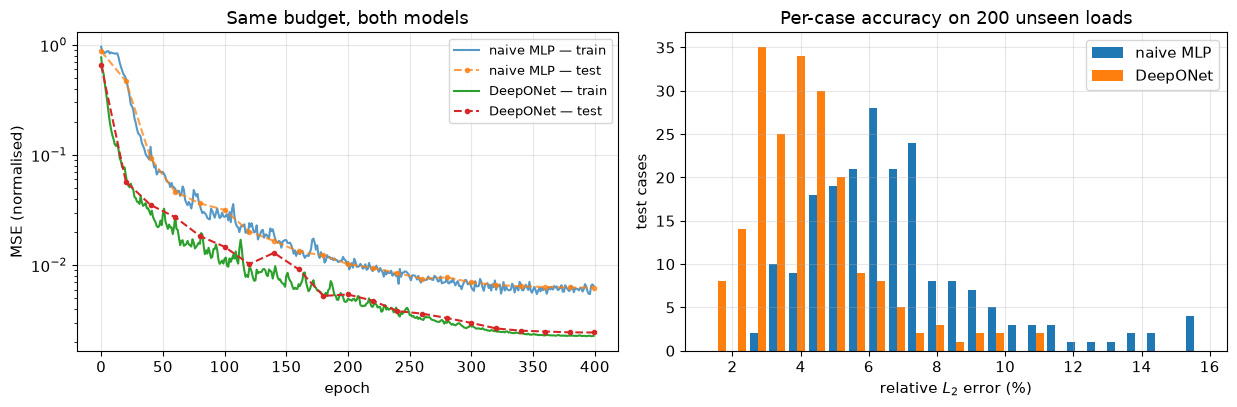

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax[0].semilogy(h_naive["train"], label="naive MLP — train", alpha=.75)
ax[0].semilogy(h_naive["test_epoch"], h_naive["test"], "o--", ms=3,
               label="naive MLP — test", alpha=.75)
ax[0].semilogy(h_don["train"], label="DeepONet — train")
ax[0].semilogy(h_don["test_epoch"], h_don["test"], "o--", ms=3,
               label="DeepONet — test")
ax[0].set(xlabel="epoch", ylabel="MSE (normalised)", title="Same budget, both models")
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

ax[1].hist([r_naive, r_don], bins=25, label=["naive MLP", "DeepONet"])
ax[1].set(xlabel="relative $L_2$ error (%)", ylabel="test cases",
          title="Per-case accuracy on 200 unseen loads")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

Both curves sit almost on top of their training counterparts — with 800
load cases and no label noise, neither model is overfitting (exactly the point
Module 2 made about noise).

### Best and worst test cases, field by field

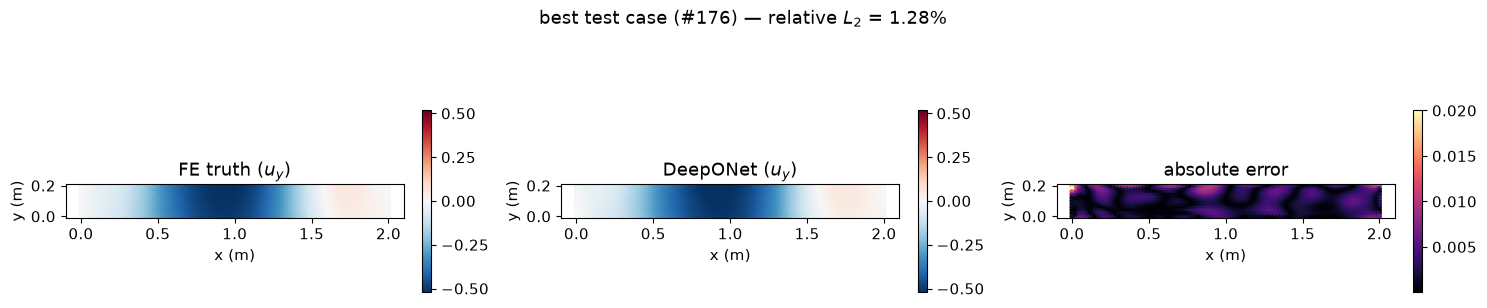

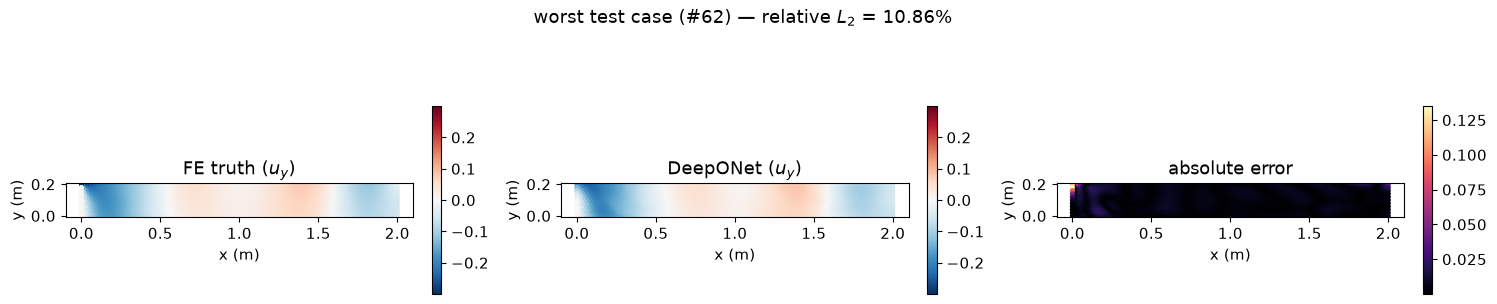

In [11]:
worst = int(np.argmax(r_don))
best = int(np.argmin(r_don))

for case, label in ((best, "best"), (worst, "worst")):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.1))
    t, p = true_te[case, :, 1], pred_te[case, :, 1]        # u_y component
    vmax = np.abs(t).max()
    for a, val, title, cmap, lim in (
            (ax[0], t, "FE truth ($u_y$)", "RdBu_r", vmax),
            (ax[1], p, "DeepONet ($u_y$)", "RdBu_r", vmax),
            (ax[2], np.abs(p - t), "absolute error", "magma", None)):
        sc = a.scatter(xy[:, 0], xy[:, 1], c=val, s=7, cmap=cmap,
                       vmin=-lim if lim else None, vmax=lim if lim else None)
        a.set(title=title, xlabel="x (m)", ylabel="y (m)")
        a.set_aspect("equal")
        plt.colorbar(sc, ax=a, fraction=.025)
    fig.suptitle(f"{label} test case (#{case}) — relative $L_2$ = "
                 f"{r_don[case]:.2f}%", y=1.06)
    plt.tight_layout(); plt.show()

## Part 4 — The learned basis

The trunk never sees a load case. It is a function of position only, so the $p$
functions $t_k(x, y)$ form a **basis for every deflection field the operator can
produce**. The branch merely picks coefficients.

So: what basis did it discover?

<img src="figs/basis_analysis.png" width="720"/>

In [12]:
basis = don.basis(XY).numpy()          # (Q, 2, p)
coef = don.coeffs(U_te).numpy()        # (B, 2, p)

# Rank the modes by how much they actually contribute:
#   contribution_k = std of coefficient k  x  norm of basis function k
contrib = coef[:, 1, :].std(0) * np.linalg.norm(basis[:, 1, :], axis=0)
order = np.argsort(contrib)[::-1]

print(f"basis shape {basis.shape}  (nodes, components, modes)")
print(f"\ntop 8 modes by contribution (of {don.p}):")
for r, k in enumerate(order[:8]):
    print(f"  rank {r+1}  mode {k:>3d}   contribution {contrib[k]:.4f}")

cum = np.cumsum(contrib[order]) / contrib.sum()
n90 = int(np.searchsorted(cum, 0.90) + 1)
print(f"\n{n90} of {don.p} modes carry 90% of the total contribution")

basis shape (1314, 2, 100)  (nodes, components, modes)

top 8 modes by contribution (of 100):
  rank 1  mode  14   contribution 3.0237
  rank 2  mode  19   contribution 2.3536
  rank 3  mode  98   contribution 2.2409
  rank 4  mode  10   contribution 2.1913
  rank 5  mode  87   contribution 2.0748
  rank 6  mode  43   contribution 2.0611
  rank 7  mode  49   contribution 1.8623
  rank 8  mode  95   contribution 1.8412

82 of 100 modes carry 90% of the total contribution


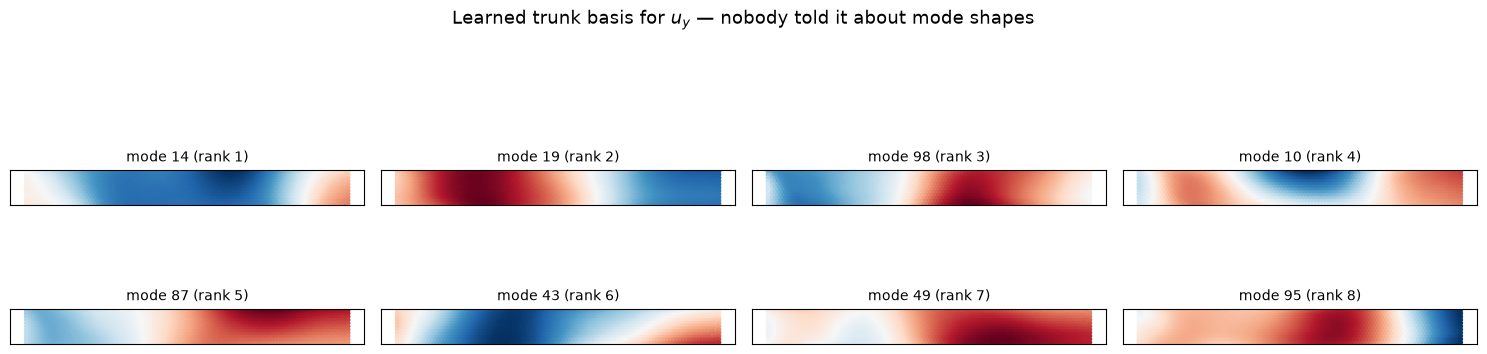

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(15, 4.4))
for r, (a, k) in enumerate(zip(axes.ravel(), order[:8])):
    b = basis[:, 1, k]
    lim = np.abs(b).max()
    a.scatter(xy[:, 0], xy[:, 1], c=b, s=5, cmap="RdBu_r", vmin=-lim, vmax=lim)
    a.set_title(f"mode {k} (rank {r+1})", fontsize=10)
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.suptitle(r"Learned trunk basis for $u_y$ — nobody told it about mode shapes",
             y=1.02)
plt.tight_layout(); plt.show()

Smooth, structured, and clearly organised by spatial frequency — with no
beam mode shape, polynomial, or Fourier term ever supplied.

But look again at the contribution numbers above. They are **flat**: the top mode
scores about 3.0 and the eighth still about 1.8, and it took 82 of the 100 modes
to reach 90% of the total. That is not what a good basis looks like. Let's find
out what is going on, because the answer is the most useful thing in this
module.

### How many dimensions does this problem actually have?

Ask the data, independently of the network. A POD (equivalently, an SVD) of the
800 training fields gives the intrinsic dimensionality of the solution
manifold.

In [14]:
from scipy.linalg import subspace_angles

# --- POD of the FE fields (u_y component) ---
Y = S_tr.numpy()[:, :, 1] * s_sd[1]                 # (800, 1314), physical units
Y_mean = Y.mean(0, keepdims=True)
U_pod, sv_pod, _ = np.linalg.svd((Y - Y_mean).T, full_matrices=False)
energy_pod = np.cumsum(sv_pod**2) / np.sum(sv_pod**2)

print("POD of the 800 FE displacement fields:")
print(f"  leading singular values: {np.array2string(sv_pod[:8], precision=1)}")
for tgt in (0.90, 0.99, 0.999):
    print(f"  modes for {tgt*100:>5.1f}% of field energy: "
          f"{int(np.searchsorted(energy_pod, tgt) + 1):>3d}")
print("\n  -> the physics lives on a roughly 6-dimensional manifold,")
print("     and we handed the trunk p = 100 basis functions.")

POD of the 800 FE displacement fields:
  leading singular values: [122.4 109.4  84.2  59.1  41.3  26.   15.6   8.4]
  modes for  90.0% of field energy:   4
  modes for  99.0% of field energy:   6
  modes for  99.9% of field energy:   8

  -> the physics lives on a roughly 6-dimensional manifold,
     and we handed the trunk p = 100 basis functions.


Six modes for 99% of the energy. The solution manifold really is
low-dimensional — so the flat contribution spectrum is not the *problem* being
high-rank. It is the network's basis being wasteful.

### Did the trunk find the right subspace?

Two separate questions, and they have different answers:

1. Does the trunk **span** the space the POD modes span?
2. Are the trunk's individual modes a **good basis** for it?

In [15]:
T_y = basis[:, 1, :]                                # (1314, 100) trunk basis
U_tr_b, sv_tr, _ = np.linalg.svd(T_y, full_matrices=False)
energy_tr = np.cumsum(sv_tr**2) / np.sum(sv_tr**2)

# How orthogonal are the 100 trunk modes? POD modes would give exactly 0.
G = T_y.T @ T_y
G_norm = G / np.sqrt(np.outer(np.diag(G), np.diag(G)))
off_diag = np.abs(G_norm[~np.eye(len(G_norm), dtype=bool)])

print(f"  condition number of the trunk basis : {sv_tr[0] / sv_tr[-1]:>12,.0f}")
print(f"  mean |cosine| between distinct modes: {off_diag.mean():>12.3f}"
      "     (POD would be 0.000)")
print()
print("  Q1: does the trunk SPAN the POD subspace?")
print("      principal angles between the leading k directions of each:")
for k in (2, 4, 6, 8):
    ang = np.degrees(subspace_angles(U_pod[:, :k], U_tr_b[:, :k]))
    print(f"        k={k:>2d}  largest angle {ang.max():>5.1f} deg")

  condition number of the trunk basis :      224,334
  mean |cosine| between distinct modes:        0.373     (POD would be 0.000)

  Q1: does the trunk SPAN the POD subspace?
      principal angles between the leading k directions of each:
        k= 2  largest angle  12.1 deg
        k= 4  largest angle  10.7 deg
        k= 6  largest angle  82.4 deg
        k= 8  largest angle  87.7 deg


Both answers at once.

**Yes, it found the space — the important part of it.** The trunk's leading four
directions sit within about 12 degrees of the four leading POD modes, and those
four carry ~93% of the field energy. The network independently rediscovered the
dominant deformation modes of a cantilever from 800 solutions. That is a real
result and it is why the pictures above look like mode shapes.

**No, it is not a good basis.** Three measurements say so:

- **Non-orthogonal.** The mean absolute cosine between distinct trunk modes is
  around 0.4. POD modes are orthogonal by construction; these overlap heavily and
  encode the same information many times over.
- **Catastrophically ill-conditioned.** A condition number in the hundreds of
  thousands. The 100 modes are very nearly linearly dependent.
- **Unordered past the leading few.** At $k = 6$ one principal angle jumps to
  above 80 degrees, and it only gets worse from there. The trunk's sixth direction
  has nothing to do with the POD's sixth. Nothing in the loss asked for an
  ordering, so there isn't one.

### The consequence: you cannot truncate it

POD comes with the Eckart-Young guarantee — keep the top $k$ modes and you have
the provably best rank-$k$ approximation of the data. A DeepONet trunk comes with
no such promise, and here is what that costs. (The two columns are not measuring
identical things: POD reconstructs the *training* fields it was computed from,
while the DeepONet predicts *unseen* ones. Read the shapes of the two curves, not
the gap at any single $k$.)

      k   DeepONet top-k    POD top-k
      1           97.15%       79.16%
      2           94.46%       57.45%
      5           88.35%       15.85%
     10           79.07%        0.56%
     20           65.40%        0.00%
     50           35.38%        0.00%
    100            4.13%        0.00%


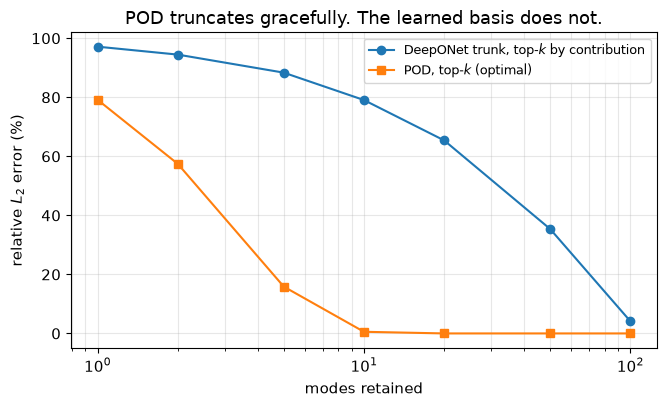

In [16]:
def truncated_pred(model, U, XY, keep):
    """Reconstruct using only the `keep` highest-contribution trunk modes."""
    B = model.coeffs(U).numpy()
    Tk = model.basis(XY).numpy()
    sel = order[:keep]
    out = np.einsum("bop,qop->bqo", B[:, :, sel], Tk[:, :, sel])
    return (out + model.bias.detach().numpy()) * s_sd


keeps = [1, 2, 5, 10, 20, 50, don.p]
errs = [rel_l2(truncated_pred(don, U_te, XY, k), true_te).mean() for k in keeps]

pod_errs = []
for k in keeps:
    coef = (Y - Y_mean) @ U_pod[:, :k]
    rec = coef @ U_pod[:, :k].T + Y_mean
    pod_errs.append(np.linalg.norm(rec - Y) / np.linalg.norm(Y) * 100)

print(f"  {'k':>5s} {'DeepONet top-k':>16s} {'POD top-k':>12s}")
for k, e, pe in zip(keeps, errs, pod_errs):
    print(f"  {k:>5d} {e:>15.2f}% {pe:>11.2f}%")

plt.figure(figsize=(6.8, 4.2))
plt.semilogx(keeps, errs, "o-", label="DeepONet trunk, top-$k$ by contribution")
plt.semilogx(keeps, pod_errs, "s-", label="POD, top-$k$ (optimal)")
plt.xlabel("modes retained"); plt.ylabel("relative $L_2$ error (%)")
plt.title("POD truncates gracefully. The learned basis does not.")
plt.legend(fontsize=9); plt.grid(True, which="both", alpha=.3)
plt.tight_layout(); plt.show()

POD falls below 1% by 10 modes and keeps collapsing. The DeepONet basis,
truncated the same way, is still ~35% wrong at 50 of 100 modes and only becomes
usable when essentially all of them are kept — because the information is smeared
across every mode, and dropping any destroys cancellations the network relied on.

**So: a DeepONet is a learned spectral method with an unmanaged basis.** It finds
the right subspace and represents it wastefully. That matters when you want to
compress the model, interpret the modes beyond the leading few, or trust the mode
count as a rank estimate.

Three standard fixes, in increasing order of effort:

- **Orthogonalise after training.** A QR or SVD of the trunk matrix, as we just
  did, gives an ordered orthonormal basis for the same span — free, and enough for
  interpretation.
- **Penalise non-orthogonality during training.** Add $\|T^\top T - I\|^2$ to the
  loss and the trunk comes out closer to POD-like.
- **POD-DeepONet.** Skip the learning entirely for the trunk: compute POD modes
  from the training fields and let the branch learn only the coefficients. Often
  more accurate *and* smaller, at the cost of a fixed output basis.

The honest summary is that the basis picture is the most interesting thing a
DeepONet gives you and the part most in need of scrutiny. A pretty mode plot is
not evidence of a well-conditioned model.

## Part 5 — Zero-shot prediction, and the limits

The claim that started the module: a new load case costs one forward pass, not a
retrain. Let's price it.

In [17]:
new_cases = U_te[:32]

t0 = time.time()
with torch.no_grad():
    _ = don(new_cases, XY)
t_infer = time.time() - t0

print(f"  32 unseen load cases, full 1314-node field each")
print(f"    DeepONet inference : {t_infer*1000:>9.1f} ms   "
      f"({t_infer/32*1000:.2f} ms per case)")
print(f"    DeepONet training  : {h_don['seconds']:>9.1f} s    (once, amortised)")
print()
print("  For comparison, from Module 4: a PINN needs a full retrain per load")
print("  case -- seconds to minutes each, and it never gets cheaper.")
print(f"\n  Speedup for a 1000-case design study: roughly "
      f"{1000 * 4.0 / (h_don['seconds'] + 1000 * t_infer / 32):,.0f}x")
print("  (taking 4 s per PINN solve, the fast end of what we measured)")

  32 unseen load cases, full 1314-node field each
    DeepONet inference :       2.1 ms   (0.07 ms per case)
    DeepONet training  :      24.9 s    (once, amortised)

  For comparison, from Module 4: a PINN needs a full retrain per load
  case -- seconds to minutes each, and it never gets cheaper.

  Speedup for a 1000-case design study: roughly 160x
  (taking 4 s per PINN solve, the fast end of what we measured)


### Querying points that are not FE nodes

The trunk takes any $(x, y)$, so we can evaluate the field on a grid the mesh
never had. This is the mesh-free property, and it is genuinely useful for
post-processing.

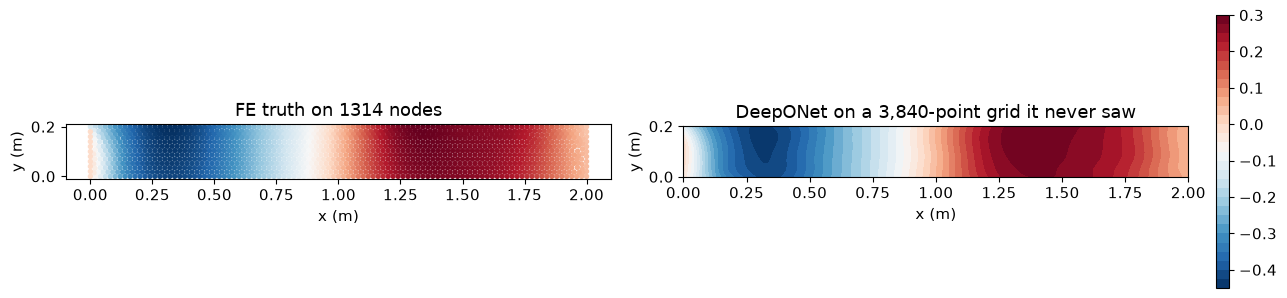

In [18]:
gx, gy = np.meshgrid(np.linspace(0, 2, 160), np.linspace(0, 0.2, 24))
grid = np.stack([gx.ravel(), gy.ravel()], 1)
XY_grid = T(2 * (grid - xy_lo) / (xy_hi - xy_lo) - 1)

with torch.no_grad():
    on_grid = (don(U_te[:1], XY_grid).numpy() * s_sd)[0, :, 1]

fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
ax[0].scatter(xy[:, 0], xy[:, 1], c=true_te[0, :, 1], s=8, cmap="RdBu_r")
ax[0].set(title=f"FE truth on {N_NODES} nodes", xlabel="x (m)", ylabel="y (m)")
im = ax[1].contourf(gx, gy, on_grid.reshape(gx.shape), levels=30, cmap="RdBu_r")
ax[1].set(title=f"DeepONet on a {gx.size:,}-point grid it never saw",
          xlabel="x (m)", ylabel="y (m)")
for a in ax:
    a.set_aspect("equal")
plt.colorbar(im, ax=ax[1], fraction=.025)
plt.tight_layout(); plt.show()

### 800 FE solves, a fixed sensor grid, and no enforced physics

**The training data is the expensive part.** We used 800 finite element solves.
DeepONet moved the cost from query time to a one-off offline campaign — it did not
remove it. The economics only work if you will make many queries.

**It only knows the family it was trained on.** Our loads were Gaussian random
field draws with a particular length scale. Feed it a point load, or a GRF with a
much shorter correlation length, and it will extrapolate — badly, and without
warning. This is the UAT domain caveat from Module 2, now applying to a space of
*functions*, where "outside the training distribution" is much harder to detect.

**The input grid is fixed.** Change your sensor layout and the branch network is
invalid. Fourier Neural Operators address exactly this by working in Fourier
space, giving discretisation invariance — train at one resolution, evaluate at
another.

**No physics is enforced.** This is a purely data-driven fit. Nothing in the loss
requires equilibrium, and the predicted field can violate it.

## Summary

| | |
| --- | --- |
| **Operators map functions to functions** | Discretise the input at $m$ sensors; the output stays mesh-free. |
| **Chen & Chen (1995) gives the architecture** | $\mathcal{G}(u)(y) \approx \sum_k b_k(u)\,t_k(y)$ — branch times trunk, read literally. |
| **The factorisation is the efficiency** | The trunk is computed once per batch and shared across all query points; the naive MLP repeats the input 1314 times. |
| **The trunk is a learned basis** | Smooth, increasing-frequency modes that nobody specified — a learned spectral method, and a low-rank diagnostic. |
| **Queries become free, training does not** | 800 FE solves offline buys millisecond inference. Worth it only for many-query workflows. |
| **It knows only its training family** | Out-of-distribution input *functions* fail silently. |
| **PI-DeepONet closes the loop** | Add Module 4's residual to Module 5's loss and shed the labelled data. |

### Formula, network, explanation, physics, operator

**Module 1** fit a formula. **Module 2** replaced the formula with a network when
we no longer knew the right features. **Module 3** interrogated the network.
**Module 4** replaced the data with physics. **Module 5** replaced one solution
with the solution operator.

### Go deeper

- [SciML — DeepONet from scratch](https://kks32-courses.github.io/sciml/02-deeponet/deeponet.html)
- [SciML — physics-informed DeepONet](https://kks32-courses.github.io/sciml/02-deeponet/pideeponet.html)
- [SciML — how to read a DeepONet](https://kks32-courses.github.io/sciml/02-deeponet/deeponet-explanation.html)
- [SciML — the batched einsum, in detail](https://kks32-courses.github.io/sciml/02-deeponet/einsum.html)
- [SciML — Fourier Neural Operators](https://kks32-courses.github.io/sciml/05-fno/fno.html)
- [SciML — function encoders](https://kks32-courses.github.io/sciml/03-function-encoder/03-function-encoder.html)
- [DesignSafe DeepONet training](https://github.com/DesignSafe-Training/deeponet) — the original JAX/Flax version of this example, by Somdatta Goswami
- Lu, Jin & Karniadakis (2019), *DeepONet* · Chen & Chen (1995), the operator UAT ·
  Li et al. (2020), *Fourier Neural Operator*